Accuracy: 0.872

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        59
           1       0.88      0.88      0.88        66

    accuracy                           0.87       125
   macro avg       0.87      0.87      0.87       125
weighted avg       0.87      0.87      0.87       125

Confusion Matrix:
 [[51  8]
 [ 8 58]]


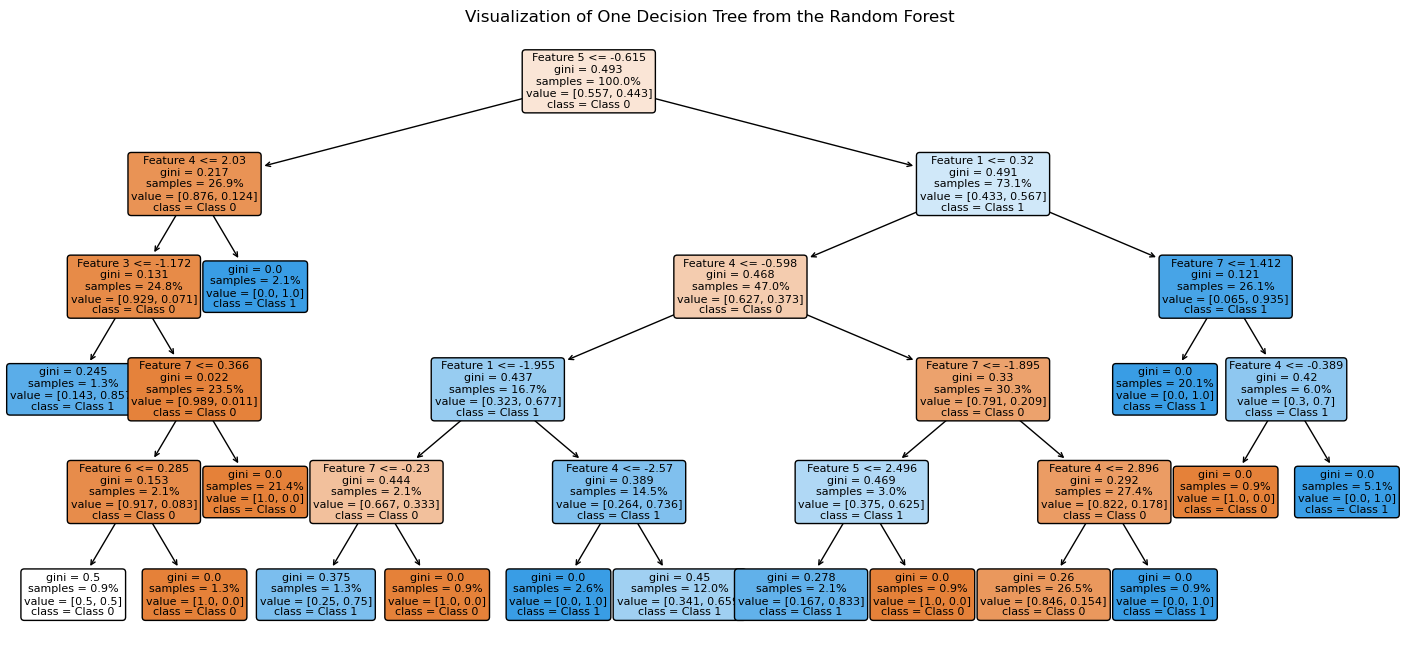

In [4]:
# Random Forest Classification Example (Manually Tuned)
# ------------------------------------------------------
# This example demonstrates how to handpick key hyperparameters for a RandomForestClassifier,
# train the model, visualize one of the trees, and evaluate its performance.

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------
# 1. Create a simple classification dataset
# -----------------------------------------------------
X, y = make_classification(
    n_samples=500,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------------------------------
# 2. Define Random Forest with chosen hyperparameters
# -----------------------------------------------------
"""
Key hyperparameters set here:

- n_estimators=100: number of trees in the forest
- max_depth=5: limits how deep each tree can grow (controls overfitting)
- min_samples_split=4: minimum number of samples required to split an internal node
- min_samples_leaf=2: minimum number of samples required to be at a leaf node
- max_features='sqrt': number of features considered for splitting at each node
- bootstrap=True: whether to use bootstrap samples
- random_state=42: ensures reproducibility
"""

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

# -----------------------------------------------------
# 3. Train the model
# -----------------------------------------------------
rf.fit(X_train, y_train)

# -----------------------------------------------------
# 4. Evaluate performance
# -----------------------------------------------------
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -----------------------------------------------------
# 5. Visualize one tree from the forest
# -----------------------------------------------------
# Extract one tree (e.g., the first one)
one_tree = rf.estimators_[0]

plt.figure(figsize=(18, 8))
plot_tree(
    one_tree,
    filled=True,
    feature_names=[f"Feature {i}" for i in range(X.shape[1])],
    class_names=["Class 0", "Class 1"],
    rounded=True,
    proportion=True,
    fontsize=8
)
plt.title("Visualization of One Decision Tree from the Random Forest")
plt.show()


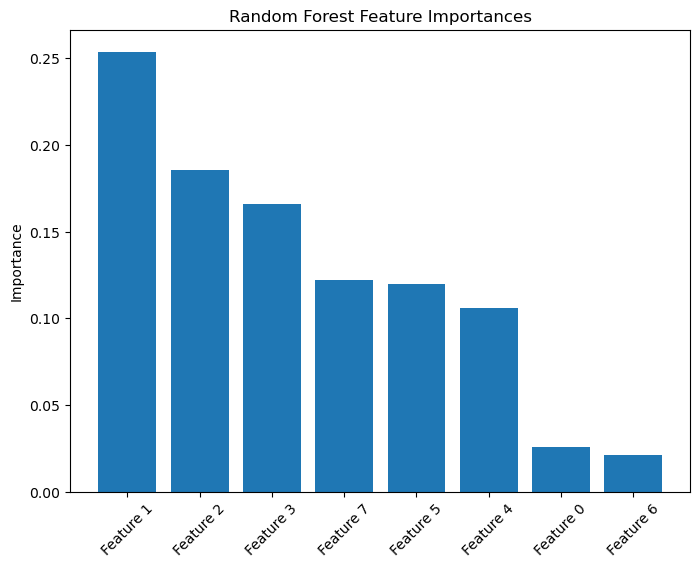

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming rf is your trained Random Forest
feature_names = [f"Feature {i}" for i in range(X.shape[1])]
importances = rf.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.ylabel("Importance")
plt.show()


Accuracy: 0.872

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.86        59
           1       0.87      0.89      0.88        66

    accuracy                           0.87       125
   macro avg       0.87      0.87      0.87       125
weighted avg       0.87      0.87      0.87       125

Confusion Matrix:
 [[50  9]
 [ 7 59]]


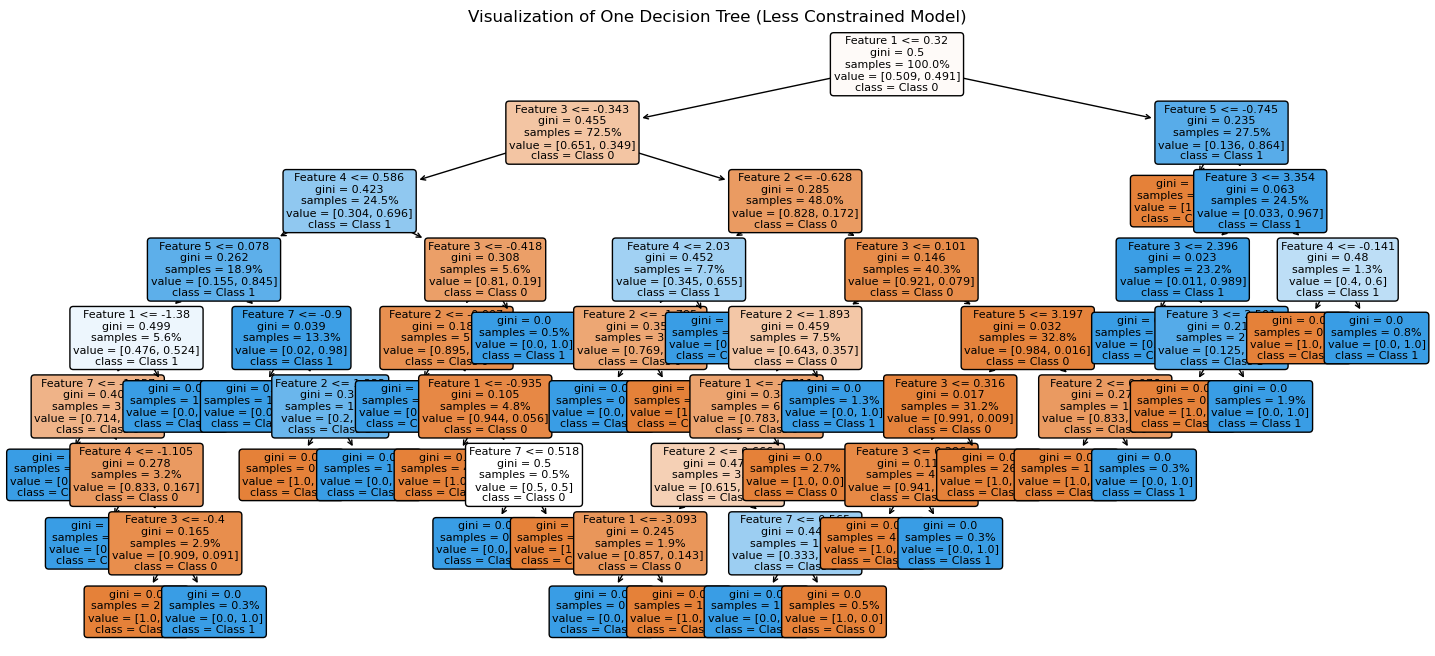

In [4]:
# Random Forest Classification Example (Alternative Hyperparameters)
# -------------------------------------------------------------------
# Same dataset as before, but with different hyperparameters to show how
# model complexity and performance can change.

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------
# 1. Create the same classification dataset
# -----------------------------------------------------
X, y = make_classification(
    n_samples=500,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------------------------------
# 2. Define Random Forest with a different configuration
# -----------------------------------------------------
"""
New hyperparameters:

- n_estimators=200: more trees → potentially more stable predictions
- max_depth=None: trees can grow fully (more complex)
- min_samples_split=2: allows finer splits
- min_samples_leaf=1: allows smaller leaves
- max_features=None: considers all features at every split (less randomness)
- bootstrap=False: uses the entire dataset for every tree (less diversity)
- random_state=42: for reproducibility
"""

rf_alt = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    bootstrap=False,
    random_state=42
)

# -----------------------------------------------------
# 3. Train the model
# -----------------------------------------------------
rf_alt.fit(X_train, y_train)

# -----------------------------------------------------
# 4. Evaluate performance
# -----------------------------------------------------
y_pred_alt = rf_alt.predict(X_test)
accuracy_alt = accuracy_score(y_test, y_pred_alt)
print(f"Accuracy: {accuracy_alt:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_alt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_alt))

# -----------------------------------------------------
# 5. Visualize one tree from the forest
# -----------------------------------------------------
one_tree_alt = rf_alt.estimators_[0]

plt.figure(figsize=(18, 8))
plot_tree(
    one_tree_alt,
    filled=True,
    feature_names=[f"Feature {i}" for i in range(X.shape[1])],
    class_names=["Class 0", "Class 1"],
    rounded=True,
    proportion=True,
    fontsize=8
)
plt.title("Visualization of One Decision Tree (Less Constrained Model)")
plt.show()


In [2]:
# XGBoost Classification Example
# ------------------------------------------------------
# Demonstrates using XGBoost for a classification task,
# evaluating performance, and comparing predictions.

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------
# 1. Create a simple classification dataset
# -----------------------------------------------------
X, y = make_classification(
    n_samples=500,
    n_features=8,
    n_informative=5,
    n_redundant=1,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# -----------------------------------------------------
# 2. Define XGBoost Classifier
# -----------------------------------------------------
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',  # binary classification
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',       # required to avoid warning
    random_state=42
)

# -----------------------------------------------------
# 3. Train the model
# -----------------------------------------------------
xgb_clf.fit(X_train, y_train)

# -----------------------------------------------------
# 4. Evaluate performance
# -----------------------------------------------------
y_pred = xgb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))




Accuracy: 0.912

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.90        59
           1       0.90      0.94      0.92        66

    accuracy                           0.91       125
   macro avg       0.91      0.91      0.91       125
weighted avg       0.91      0.91      0.91       125

Confusion Matrix:
 [[52  7]
 [ 4 62]]


c:\Users\micci\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:16:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


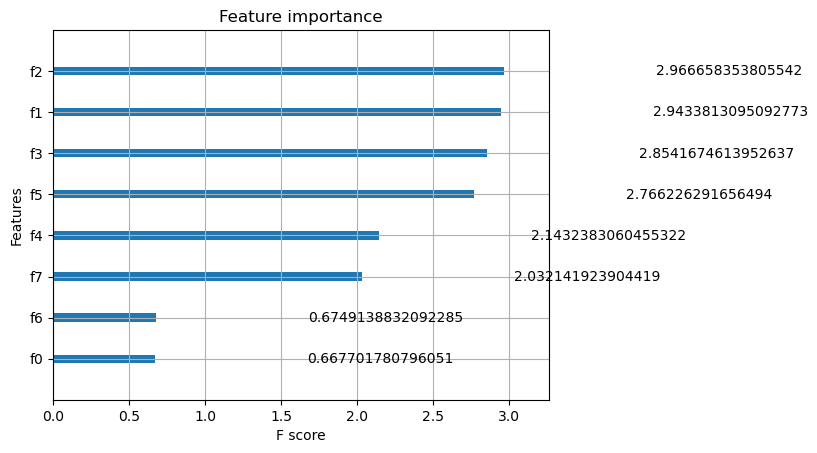

In [6]:
from xgboost import plot_importance

plot_importance(xgb_clf, importance_type='gain', max_num_features=8)
plt.show()
